# Домашнее задание: подбор гиперпараметров бустинга и интерпретация модели с SHAP

**Ожидаемое время решения:** 1–1.5 часа.

## Задание

1. Постройте модель градиентного бустинга (LightGBM) на предложенном датасете, подобрав гиперпараметры с помощью Optuna. Исследуйте результаты подбора:
   1. Постройте **parallel coordinate plot** — какие гиперпараметры, судя по графику, можно зафиксировать (не тюнить), а какие критически важны?
   2. Постройте **contour plot** для пары наиболее важных гиперпараметров — хорошо ли подобрана сетка (границы) поиска, или оптимум упирается в край диапазона?
2. Исследуйте SHAP-значения обученной модели:
   1. По **beeswarm** и/или **bar plot** определите, какие признаки являются шумовыми (не влияют на предсказание).
   2. По **dependence plot** найдите интересные попарные взаимодействия признаков.

## Датасет

Мы работаем с синтетическим датасетом **кредитного скоринга** (предсказание дефолта заёмщика).

Формат сдачи: заполненный ноутбук `homework.ipynb`, который можно запустить целиком (Run All) без ошибок.

## 0. Импорт библиотек и генерация датасета

Ниже — готовый код для генерации датасета. Его не нужно менять, просто выполните ячейки.

In [ ]:
# pip install lightgbm optuna plotly shap seaborn pandas numpy matplotlib scikit-learn

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

df = pd.read_csv('credit_default_dataset.csv')
print(df.shape)
print(f"Доля дефолтов: {df['default'].mean():.3f}")
df.head()

(5000, 10)
Доля дефолтов: 0.329


,credit_score,debt_to_income,num_late_payments,employment_years,loan_amount,age,num_dependents,random_noise_1,random_noise_2,default
0,791.124188,0.392597,0,11.983732,30789.448624,40.644553,1,-0.459744,-0.302889,0
1,682.012577,0.048017,2,2.989243,16185.904729,63.539670,0,-0.101710,-0.477970,0
2,728.299039,0.220371,2,1.969566,47967.595997,39.928274,1,-0.101684,-0.676613,0
3,829.271456,0.573167,4,5.233681,33381.566076,62.364786,2,-1.101363,-0.439043,1
4,799.404639,0.451384,4,4.912667,9389.584941,32.648320,0,-0.950643,0.333650,0


### Разбиение на train/test

In [9]:
feature_cols = [c for c in df.columns if c != 'default']
X = df[feature_cols]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((3500, 9), (1500, 9))

## 1. Подбор гиперпараметров LightGBM с помощью Optuna (4 балла)

**Задание:** напишите objective-функцию для Optuna, которая обучает `lgb.train` с подсказанными (`trial.suggest_*`) гиперпараметрами и возвращает AUC на валидационной выборке (`X_test`, `y_test`). Используйте early stopping.

Рекомендуемое пространство поиска (можно скорректировать):
- `num_leaves`: int, [10, 200]
- `learning_rate`: float, [0.01, 0.3], log scale
- `feature_fraction`: float, [0.5, 1.0]
- `bagging_fraction`: float, [0.5, 1.0]
- `bagging_freq`: int, [1, 10]
- `lambda_l1`: float, [1e-8, 10.0], log scale
- `lambda_l2`: float, [1e-8, 10.0], log scale

Запустите не менее 50 trials.

In [10]:
import optuna

train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)


def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': RANDOM_STATE,
        # TODO: задайте гиперпараметры через trial.suggest_*
        'num_leaves': trial.suggest_int('num_leaves', 10, 200),       
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),    
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0), 
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0), 
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),     
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),        
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),        
    }

    # TODO: обучите модель с early stopping и верните AUC на валидации
    model = lgb.train(
        params,
        train_data,
        num_boost_round=100,
        valid_sets=[valid_data],
        valid_names=['valid'],
        callbacks=[lgb.early_stopping(10, verbose=False)]
    )

    preds = model.predict(X_test, num_iteration=model.best_iteration)
    return roc_auc_score(y_test, preds)
    

# TODO: создайте study и запустите optimize (n_trials >= 50)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print("Best params:", study.best_params)
print("Best AUC:", study.best_value)

[I 2026-08-16 13:19:25,126] A new study created in memory with name: no-name-c2e0ec0f-faa8-453a-b453-7b34471ce003
[I 2026-08-16 13:19:25,320] Trial 0 finished with value: 0.8049152887193297 and parameters: {'num_leaves': 168, 'learning_rate': 0.08284665306533125, 'feature_fraction': 0.5680990677006135, 'bagging_fraction': 0.556496622155034, 'bagging_freq': 5, 'lambda_l1': 0.0008214394211163124, 'lambda_l2': 4.5422162890762395e-05}. Best is trial 0 with value: 0.8049152887193297.
[I 2026-08-16 13:19:25,468] Trial 1 finished with value: 0.8152828778671006 and parameters: {'num_leaves': 26, 'learning_rate': 0.07611234567433077, 'feature_fraction': 0.7827910946173116, 'bagging_fraction': 0.9854170887816462, 'bagging_freq': 5, 'lambda_l1': 5.269599415363111, 'lambda_l2': 0.01144670592022778}. Best is trial 1 with value: 0.8152828778671006.
[I 2026-08-16 13:19:25,693] Trial 2 finished with value: 0.8026915042975038 and parameters: {'num_leaves': 125, 'learning_rate': 0.05163196768879063, 'fe

Best params: {'num_leaves': 103, 'learning_rate': 0.17749754162195502, 'feature_fraction': 0.8476948720841488, 'bagging_fraction': 0.946088532047128, 'bagging_freq': 2, 'lambda_l1': 8.724876542218485, 'lambda_l2': 0.12614969740274742}
Best AUC: 0.8194625451454423


### 1.1 Обучение финальной модели с лучшими параметрами

**Задание:** обучите LightGBM с параметрами `study.best_params` на полном train, сохраните модель в переменную `model_lgb` — она понадобится для SHAP-анализа далее.

In [11]:
best_params = study.best_params.copy()
best_params.update({'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': RANDOM_STATE})

# TODO: обучите финальную модель model_lgb с best_params
model_lgb = lgb.train(
    best_params,
    train_data,
    num_boost_round=100,
    valid_sets=[valid_data],
    valid_names=['valid'],
    callbacks=[lgb.early_stopping(10, verbose=False)]
)

# TODO: посчитайте и выведите AUC на train и test
pred_train = model_lgb.predict(
X_train, num_iteration=model_lgb.best_iteration
)
pred_test = model_lgb.predict(
X_test, num_iteration=model_lgb.best_iteration
)
print("Train AUC:", roc_auc_score(y_train, pred_train))
print("Test AUC:", roc_auc_score(y_test, pred_test))


Train AUC: 0.8921866127200455
Test AUC: 0.8194625451454423


### 1.2 Parallel coordinate plot

**Задание:** постройте parallel coordinate plot для `study`. Изучите график и ответьте письменно (в markdown-ячейке ниже): какие гиперпараметры, судя по графику, слабо влияют на итоговый AUC и их можно было бы зафиксировать на разумном значении по умолчанию, чтобы сократить пространство поиска?

In [21]:
from optuna.visualization import plot_parallel_coordinate, plot_param_importances, plot_contour

plot_parallel_coordinate(study).show()
plot_param_importances(study).show()

**Ваш ответ:** Первый кандидат на выбывание - это bagging_freq, так как по графику видно, что все тёмно-синие линие (говорящие о высоком скоре) распределены рандомно по всей длине вертикальной линии, то есть никакого тренда нет и есть смысл сделать его значением по умолчанию. У lambda_l1 все темно-синие линии расположены в диапазоне от 
1.6e-08 до 0.01. Как я понял, модели не подходит l1-регуляризация, так как она зануляет важные веса и портят метрику, возможно стоит зафиксировать значения в районе 0 или сузить диапазон поиска до микроскопических значений. Резюмируя, стопроцентно стоит фиксировать только bagging_freq и попробовать lambda_l1, остальные гиперпараметры фиксировать не стоит 

### 1.3 Contour plot

**Задание:** выберите два гиперпараметра, которые (судя по `plot_param_importances`) сильнее всего влияют на метрику, и постройте для них contour plot. Ответьте: находится ли найденный оптимум внутри заданных границ поиска, или он «упирается» в край диапазона? Если упирается — как нужно было бы изменить границы поиска?

In [15]:
# TODO: постройте plot_param_importances(study)
# TODO: выберите два наиболее важных гиперпараметра и постройте для них plot_contour(study, params=[...])
plot_contour(
study, params=['num_leaves', 'learning_rate']
).show()


**Ваш ответ:** По оси Y (num_leaves) лучшие значения целевой метрики расположены в самом низу графика - на нижней границе диапазона. По оси X (learning_rate) лучшние значения расположены в диапазоне 0.1 - 0.3. Очевидно, что найденный оптимум упирается в нижний край диапазона. Для num_leaves нужно сдвинуть нижнюю границу, а для learning_rate границу наоборот сдвинуть вверх.

## 2. Интерпретация модели с помощью SHAP (4 балла)

**Задание:** пересчитайте SHAP-значения для обученной модели `model_lgb` на тестовой выборке с помощью `shap.TreeExplainer`.

In [18]:
import shap

explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

feature_names = feature_cols

/Users/dmitriy/Учеба/Risk Intensive/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### 2.1 Beeswarm / bar plot — поиск шумовых признаков

**Задание:** постройте beeswarm plot (`shap.summary_plot`) и bar plot (агрегированная важность). Определите, какие признаки являются шумовыми (SHAP value близок к нулю для всех наблюдений). Совпадает ли ваш список с тем, что вы ожидали, глядя на названия признаков?

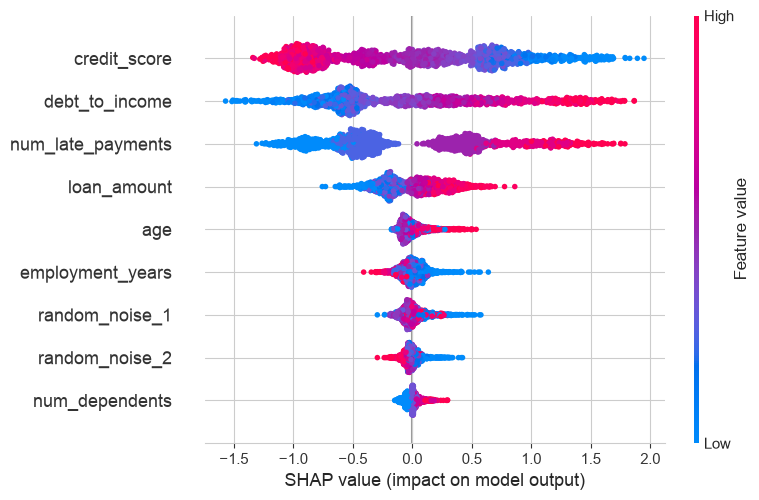

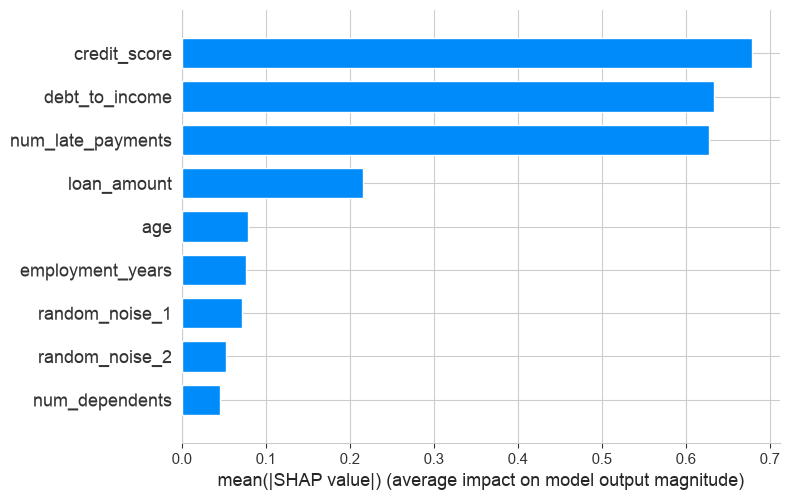

In [17]:
# TODO: постройте beeswarm plot
shap.summary_plot(
    shap_values_pos, X_test,
    feature_names=feature_names, show=True
)

# TODO: постройте bar plot (агрегированная важность)
shap.summary_plot(
    shap_values_pos, X_test,
    feature_names=feature_names,
    plot_type='bar', show=True
)


**Ваш ответ:** судя по графику beeswarm шумовыми являются: random_noise_1, random_noise_2 и num_dependents, хотя вообще меня смущает и age (он болтается около нуля, но по сути должен быть достаточно информативным, причем у него виднеется очевидная линейная связь: чем старше - тем больше предсказание модели). Получается, что ожидаемый список (random_noise_1 и random_noise_2) совпадает с реальным лишь наполовину. Причем из bar plot видно, что num_dependents имеет даже меньший вклад в таргет, чем специально сгенерированные шумовые фичи.


### 2.2 Dependence plot — поиск попарных взаимодействий

**Задание:** постройте dependence plot для 2-3 наиболее важных признаков (по умолчанию SHAP сам подберёт цвет по признаку с наибольшим взаимодействием). Найдите признак, у которого зависимость SHAP value от значения самого признака выглядит по-разному в зависимости от цвета (значения второго признака) — это и есть взаимодействие. Дополнительно постройте dependence plot с явно заданным `interaction_index`, чтобы проверить гипотезу о конкретной паре признаков.

Топ-3 признака по среднему |SHAP|: ['credit_score', 'debt_to_income', 'num_late_payments']


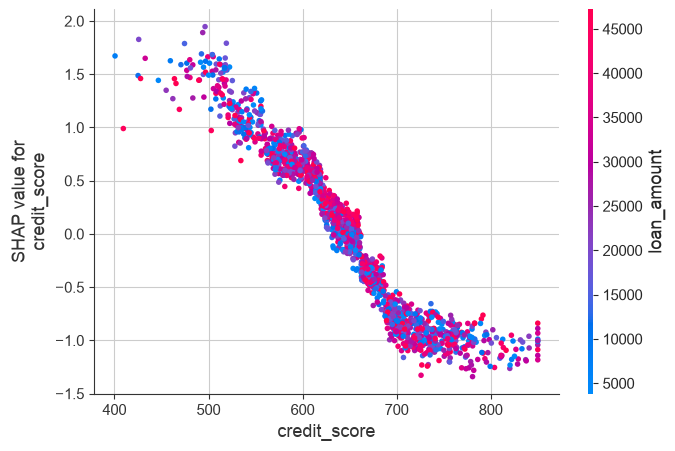

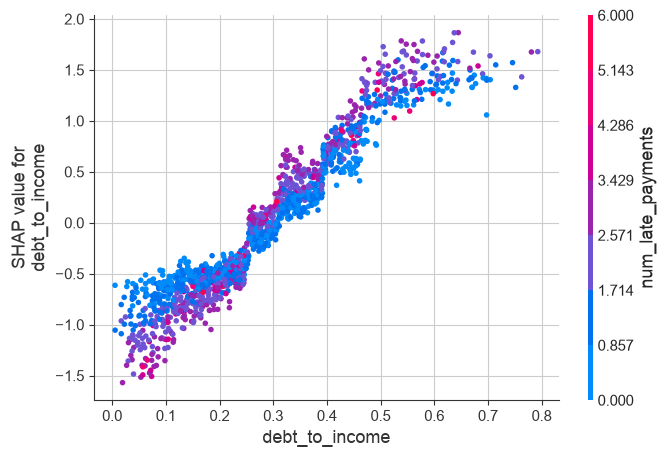

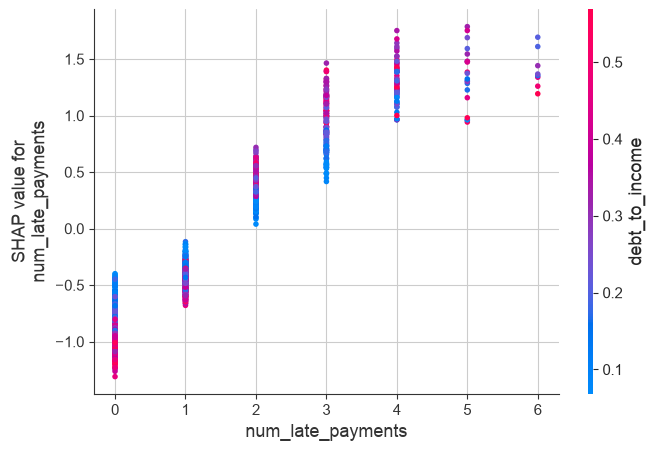

Проверяем взаимодействие: credit_score × debt_to_income


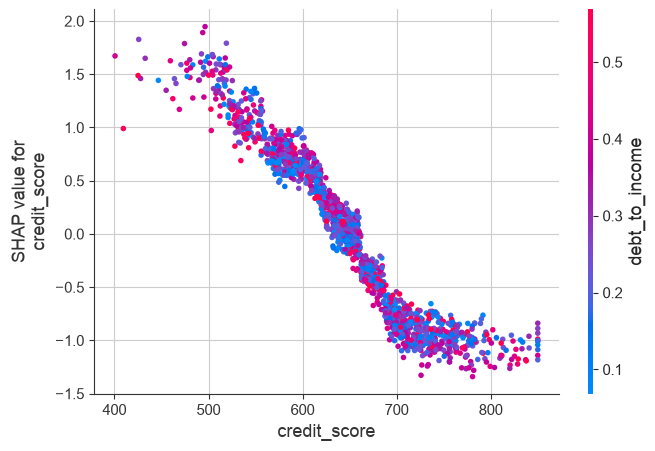

In [22]:
# Dependence plot для 3 наиболее важных признаков
# Важность определяем по среднему абсолютному SHAP на тестовой выборке.
shap_importance = np.abs(shap_values_pos).mean(axis=0)
top_indices = np.argsort(shap_importance)[::-1][:3]
top_features = [feature_names[i] for i in top_indices]

print("Топ-3 признака по среднему |SHAP|:", top_features)

for feature in top_features:
    shap.dependence_plot(
        feature,
        shap_values_pos,
        X_test,
        feature_names=feature_names,
        show=True
    )

# Явная проверка взаимодействия двух наиболее важных признаков:
# цветом кодируем второй по важности признак.
main_feature = top_features[0]
interaction_feature = top_features[1]

print(
    f"Проверяем взаимодействие: {main_feature} × {interaction_feature}"
)

shap.dependence_plot(
    main_feature,
    shap_values_pos,
    X_test,
    feature_names=feature_names,
    interaction_index=interaction_feature,
    show=True
)


**Ваш ответ:**

По SHAP наиболее важными признаками являются num_late_payments, debt_to_income и credit_score. На dependence plot для num_late_payments видна очень сильная и практически монотонная зависимость: при увеличении числа просрочек SHAP-значение резко возрастает, то есть модель существенно повышает оценку риска дефолта.

При явной проверке взаимодействия num_late_payments × debt_to_income видно, что цветовая шкала по debt_to_income немного меняет положение точек при одинаковом числе просрочек. Это говорит о наличии взаимодействия: влияние числа просрочек частично зависит от уровня долговой нагрузки. При этом основной эффект всё же задаётся num_late_payments, а взаимодействие является дополнительным и не столь сильным.




## 3. Итоговые выводы (3 балла)

Кратко (в виде bullet points) резюмируйте:
- Какие гиперпараметры оказались важны, а какие можно было не тюнить?
- Была ли сетка поиска гиперпараметров задана удачно?
- Какие признаки оказались шумовыми?
- Какое взаимодействие признаков вы обнаружили и согласуется ли оно с вашей интуицией о кредитном риске?

**Ваш ответ:**

- **Качество модели.** После 50 trials Optuna лучший результат на валидационной/тестовой выборке составил **AUC = 0.8221**. Финальная модель показала `Train AUC = 0.8569` и `Test AUC = 0.8221`, поэтому модель обладает хорошей разделяющей способностью, при этом присутствует умеренный разрыв между train и test, то есть некоторое переобучение.

- **Гиперпараметры.** По `plot_param_importances` наиболее важным параметром оказался `num_leaves` (importance ≈ 0.583), затем `learning_rate` (≈ 0.199) и `bagging_fraction` (≈ 0.108). `feature_fraction`, `bagging_freq`, `lambda_l1` и особенно `lambda_l2` влияли заметно слабее. Поэтому в дальнейшем пространстве поиска в первую очередь имеет смысл оставлять `num_leaves` и `learning_rate`, а слабые параметры можно фиксировать или искать в существенно более узком диапазоне.

- **Границы поиска.** На contour plot оптимальная область находится у нижней границы `num_leaves`: лучший найденный trial имеет `num_leaves = 10`, то есть минимум исходного диапазона. Следовательно, диапазон для `num_leaves` стоило расширить вниз. Для `learning_rate` лучший найденный trial имеет значение около **0.086**, то есть оно находится внутри заданного диапазона `[0.01, 0.3]`; расширять верхнюю границу только на основании полученного результата необходимости нет.

- **SHAP и шумовые признаки.** На beeswarm/bar plot основными признаками оказались `num_late_payments`, `debt_to_income`, `credit_score` и `loan_amount`. `num_dependents` имеет практически нулевой вклад и является наиболее явным шумовым/малозначимым признаком. `random_noise_1` также имеет очень маленький вклад. При этом `random_noise_2` не следует автоматически считать полностью шумовым: его SHAP-вклад мал по сравнению с основными признаками, но он всё же заметен на графике. Поэтому корректнее говорить о малозначимых признаках, а не объявлять оба `random_noise_*` строго нулевыми.

- **Взаимодействия.** Наиболее содержательный dependence plot получен для `num_late_payments`. Его эффект резко возрастает с числом просрочек. При раскраске по `debt_to_income` наблюдается дополнительное расслоение точек, что указывает на взаимодействие этих признаков: влияние просрочек частично зависит от долговой нагрузки. Это соответствует интуиции кредитного риска — большое число просрочек особенно существенно при высокой долговой нагрузке.


